ML for Robotics Lab-11

Example-1: PCA

Mean-centered data:
 [[ 0.46  0.16]
 [-1.54 -1.54]
 [ 0.16  0.66]
 [-0.14 -0.04]
 [ 1.06  0.76]]
Covariance Matrix:
 [[0.938  0.8405]
 [0.8405 0.853 ]]
[1.73707382 0.05392618] [[ 0.72474155 -0.68902082]
 [ 0.68902082  0.72474155]]
Principal Component (PC1):
 [0.72474155 0.68902082]
Projected Data:
 [ 0.44362444 -2.17719404  0.57071239 -0.12902465  1.29188186]


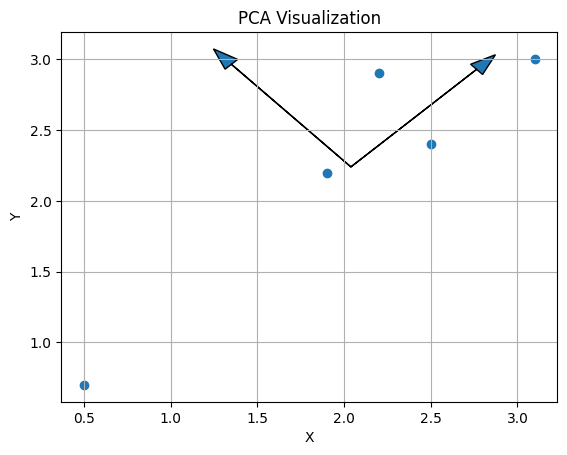

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
X = np.array([[2.5, 2.4],[0.5, 0.7],[2.2, 2.9],[1.9, 2.2],[3.1, 3.0]])
X_meaned = X - np.mean(X, axis=0)
print("Mean-centered data:\n", X_meaned)
cov_matrix = np.cov(X_meaned.T)
print("Covariance Matrix:\n", cov_matrix)
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)
print(eigen_values, eigen_vectors)
sorted_index = np.argsort(eigen_values)[::-1]
sorted_eigenvectors = eigen_vectors[:, sorted_index]
pc1 = sorted_eigenvectors[:, 0]
print("Principal Component (PC1):\n", pc1)
X_reduced = np.dot(X_meaned, pc1)
print("Projected Data:\n", X_reduced)
plt.figure()
plt.scatter(X[:,0], X[:,1])
mean = np.mean(X, axis=0)
for i in range(2):
 vec = sorted_eigenvectors[:, i]
 plt.arrow(mean[0], mean[1], vec[0], vec[1], head_width=0.1)
plt.title("PCA Visualization")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

Example-2: PCA - Reconstruct Image

Dataset shape: (70000, 784)
Components: 100, MSE: 0.005723196798245504
Components: 50, MSE: 0.011748092185972992
Components: 10, MSE: 0.03437132972324286


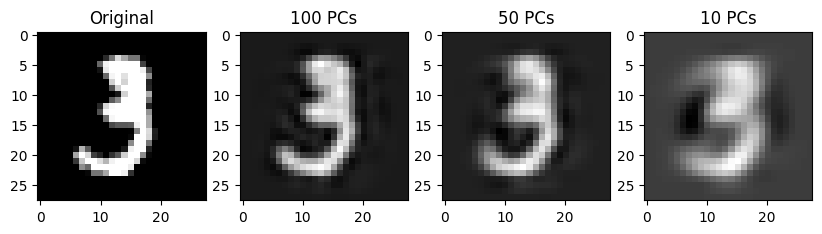

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target
print("Dataset shape:", X.shape)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
components_list = [100, 50, 10]
reconstructed_images = {}
mse_values = []
for n in components_list:
  pca = PCA(n_components=n)
  X_reduced = pca.fit_transform(X_scaled)
  X_reconstructed = pca.inverse_transform(X_reduced)
  reconstructed_images[n] = X_reconstructed
  mse = mean_squared_error(X_scaled, X_reconstructed)
  mse_values.append(mse)
  print(f"Components: {n}, MSE: {mse}")
def plot_images(original, reconstructed_dict, index=0):
  plt.figure(figsize=(10, 4))
  plt.subplot(1, len(reconstructed_dict)+1, 1)
  plt.imshow(original[index].reshape(28, 28), cmap='gray')
  plt.title("Original")
  i = 2
  for n, data in reconstructed_dict.items():
    plt.subplot(1, len(reconstructed_dict)+1,i)
    plt.imshow(data[index].reshape(28, 28), cmap='gray')
    plt.title(f"{n} PCs")
    i += 1
  plt.show()
plot_images(X_scaled, reconstructed_images, index=10)

Exercise-1: Use the Iris Dataset from Kaggle. Apply Principal Component Analysis (PCA) to reduce dimensionality and analyse the variance captured by principal components.


Dataset shape: (150, 4)
Mean-centered data:
 [[-7.43333333e-01  4.42666667e-01 -2.35800000e+00 -9.99333333e-01]
 [-9.43333333e-01 -5.73333333e-02 -2.35800000e+00 -9.99333333e-01]
 [-1.14333333e+00  1.42666667e-01 -2.45800000e+00 -9.99333333e-01]
 [-1.24333333e+00  4.26666667e-02 -2.25800000e+00 -9.99333333e-01]
 [-8.43333333e-01  5.42666667e-01 -2.35800000e+00 -9.99333333e-01]
 [-4.43333333e-01  8.42666667e-01 -2.05800000e+00 -7.99333333e-01]
 [-1.24333333e+00  3.42666667e-01 -2.35800000e+00 -8.99333333e-01]
 [-8.43333333e-01  3.42666667e-01 -2.25800000e+00 -9.99333333e-01]
 [-1.44333333e+00 -1.57333333e-01 -2.35800000e+00 -9.99333333e-01]
 [-9.43333333e-01  4.26666667e-02 -2.25800000e+00 -1.09933333e+00]
 [-4.43333333e-01  6.42666667e-01 -2.25800000e+00 -9.99333333e-01]
 [-1.04333333e+00  3.42666667e-01 -2.15800000e+00 -9.99333333e-01]
 [-1.04333333e+00 -5.73333333e-02 -2.35800000e+00 -1.09933333e+00]
 [-1.54333333e+00 -5.73333333e-02 -2.65800000e+00 -1.09933333e+00]
 [-4.33333333e-02

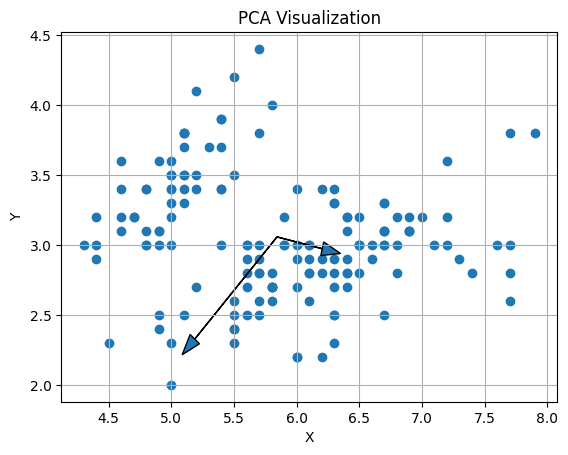

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
X = iris.data
y = iris.target
print("Dataset shape:", X.shape)
X_meaned = X - np.mean(X, axis=0)
print("Mean-centered data:\n", X_meaned)
cov_matrix = np.cov(X_meaned.T)
print("Covariance Matrix:\n", cov_matrix)
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)
print(eigen_values, eigen_vectors)
sorted_index = np.argsort(eigen_values)[::-1]
sorted_eigenvectors = eigen_vectors[:, sorted_index]
pc1 = sorted_eigenvectors[:, 0]
print("Principal Component (PC1):\n", pc1)
X_reduced = np.dot(X_meaned, pc1)
print("Projected Data:\n", X_reduced)
plt.figure()
plt.scatter(X[:,0], X[:,1])
mean = np.mean(X, axis=0)
for i in range(2):
 vec = sorted_eigenvectors[:, i]
 plt.arrow(mean[0], mean[1], vec[0], vec[1], head_width=0.1)
plt.title("PCA Visualization")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

Dataset shape: (150, 4)

Explained Variance Ratio:
PC1: 0.7296
PC2: 0.2285
PC3: 0.0367
PC4: 0.0052

Cumulative Variance:
PC1 to PC1: 0.7296
PC1 to PC2: 0.9581
PC1 to PC3: 0.9948
PC1 to PC4: 1.0000


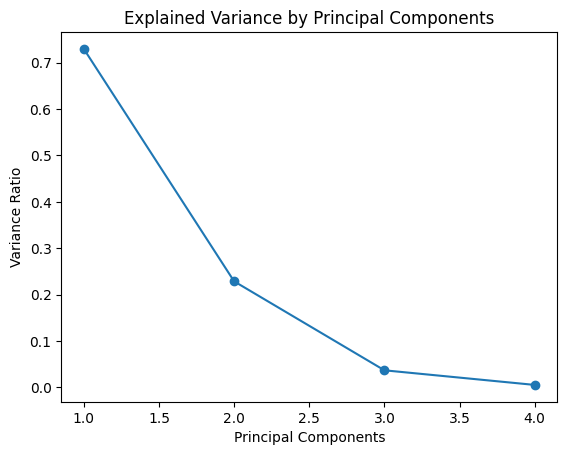

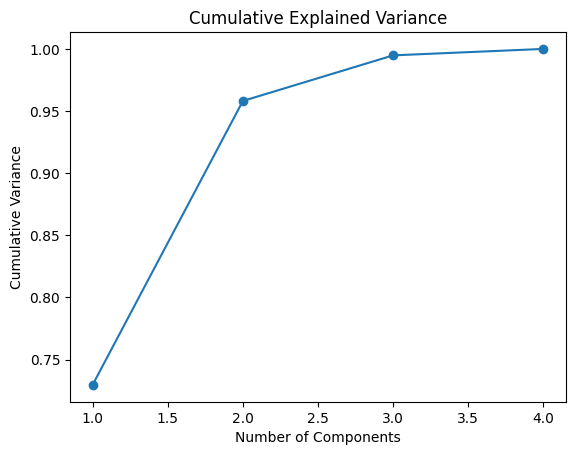

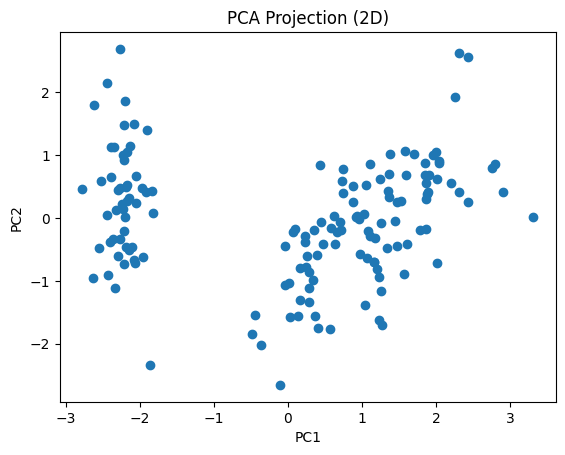

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
iris = load_iris()
X = iris.data
y = iris.target
print("Dataset shape:", X.shape)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
print("\nExplained Variance Ratio:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f}")
print("\nCumulative Variance:")
cumulative_variance = np.cumsum(explained_variance)
for i, var in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {var:.4f}")
plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.show()
plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.show()
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.title("PCA Projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Exercise-2: Apply Principal Component Analysis (PCA) to reduce multiple cricket performance metrics into 2–3 key components, and identify:

• What defines a “great player”?

• Can players be grouped into batsmen, bowlers, and all-rounders
using PCA?

https://www.kaggle.com/datasets/saivarunreddy1904/ipl-playerstats-dataset?select=IPL+dataset+final.csv

PCA reduces multiple cricket metrics into 2 key components.
PC1 represents overall player quality. PC2 distinguishes player roles
Players naturally cluster into batsmen, bowlers and all-rounders
PCA helps in talent identification, team selection and performance analysis.

Answer-1) A great player in PCA terms is a player with a high PC1 score which indicates high runs, good strike rate, good average and also contributes wickets.

Answe-2) Yes, players can be grouped into batsmen, bowlers,and all-rounders. From PCA plot we can observe that a batsman will have a high PC2 (positive side)
high runs, a good strike rate and low wickets. A bowler will have low PC2 (negative side), high wickets and low batting stats. All-rounders are mostly near center or spread across both axes and are moderate-to-high in both batting & bowling.

Dataset shape: (58, 6)

Explained Variance Ratio:
PC1: 0.3622
PC2: 0.2391
PC3: 0.1531
PC4: 0.1116
PC5: 0.0874
PC6: 0.0466

Cumulative Variance:
PC1 to PC1: 0.3622
PC1 to PC2: 0.6014
PC1 to PC3: 0.7545
PC1 to PC4: 0.8660
PC1 to PC5: 0.9534
PC1 to PC6: 1.0000


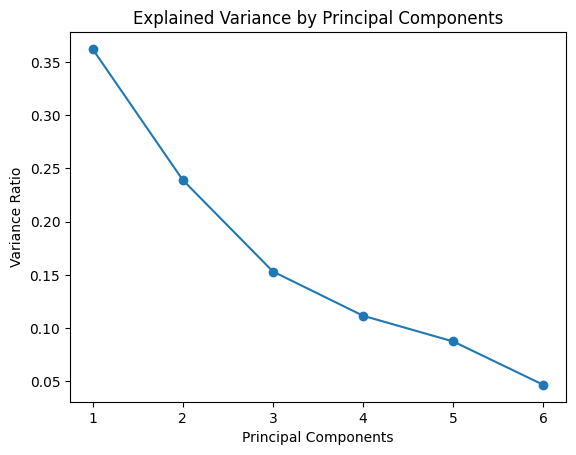

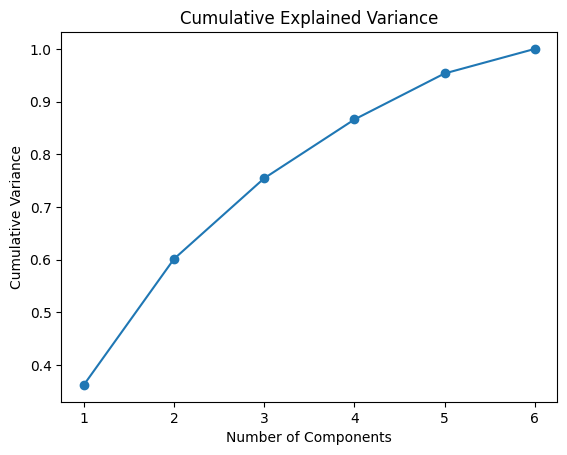

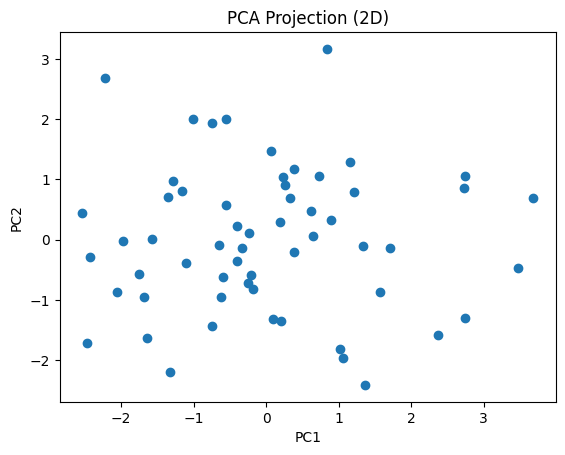

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("IPL dataset final.csv")
features = [
    'Runs', 'Avg', 'SR',
    'B_Wkts', 'B_Econ', 'B_Avg'
]

df = df.dropna(subset=features)
X = df[features]
print("Dataset shape:", X.shape)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
print("\nExplained Variance Ratio:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f}")
print("\nCumulative Variance:")
cumulative_variance = np.cumsum(explained_variance)
for i, var in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {var:.4f}")
plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.show()
plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.show()
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.title("PCA Projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [16]:
print("\nPCA Components (Feature Importance):")
print(pd.DataFrame(pca.components_, columns=features))


PCA Components (Feature Importance):
       Runs       Avg        SR    B_Wkts    B_Econ     B_Avg
0  0.581649  0.451593  0.501774  0.363270 -0.221557 -0.157855
1  0.102408  0.381827  0.248811 -0.425776  0.477825  0.610092
2  0.280513 -0.375360 -0.112331  0.619318  0.583676  0.208725
3  0.046537 -0.142885 -0.105989  0.199265 -0.611813  0.743077
4 -0.259573 -0.526371  0.807696 -0.045820 -0.019240  0.026693
5  0.709201 -0.460320 -0.100449 -0.511261 -0.085048 -0.080181
